In [1]:
%matplotlib inline
import nest_asyncio
nest_asyncio.apply()
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'monospace',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': '#fafafa',
    'axes.facecolor': '#fafafa',
})

# ¿Tienen sesgo las reseñas de Amazon?

Analizamos ~50.000 reseñas sintéticas calibradas a los patrones documentados en investigaciones reales (Hu & Liu 2004, estudios de Fakespot). Exploramos la distribución bimodal, diferencias entre reseñas verificadas y no verificadas, sesgos por categoría y detección de fraude temporal.

## 1. Setup — Generación de datos sintéticos

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

np.random.seed(2024)

N_REVIEWS = 49580  # base reviews; + 420 bombing = 50,000 exactly

# --- Categorías y sus perfiles de rating ---
# Basado en Hu & Liu (2004) y análisis de Fakespot (2020)
categories = {
    'Electrónica': {'five': 0.55, 'one': 0.20, 'mid': 0.25, 'fraud_rate': 0.18},
    'Libros':      {'five': 0.45, 'one': 0.10, 'mid': 0.45, 'fraud_rate': 0.08},
    'Belleza':     {'five': 0.60, 'one': 0.12, 'mid': 0.28, 'fraud_rate': 0.22},
    'Cocina':      {'five': 0.50, 'one': 0.14, 'mid': 0.36, 'fraud_rate': 0.12},
    'Deportes':    {'five': 0.48, 'one': 0.16, 'mid': 0.36, 'fraud_rate': 0.14},
}
cat_names = list(categories.keys())

def generate_ratings_bimodal(n, profile, verified):
    """
    Genera ratings con distribucion bimodal.
    Las no verificadas tienen mas extremos (mas 1s y 5s).
    """
    if verified:
        # Verificadas: algo menos extremas
        p5 = profile['five'] * 0.85
        p1 = profile['one'] * 0.75
    else:
        # No verificadas: mas extremas (fraude/opinion fuerte)
        p5 = min(profile['five'] * 1.20, 0.80)
        p1 = min(profile['one'] * 1.35, 0.35)

    p_mid = 1 - p5 - p1
    if p_mid < 0:
        p5 = 0.65
        p1 = 0.25
        p_mid = 0.10

    # Distribuir el segmento medio entre 2, 3, 4 estrellas
    p2 = p_mid * 0.25
    p3 = p_mid * 0.40
    p4 = p_mid * 0.35

    probs = [p1, p2, p3, p4, p5]
    probs_sum = sum(probs)
    probs = [p / probs_sum for p in probs]

    return np.random.choice([1, 2, 3, 4, 5], size=n, p=probs)

# --- Generar reviews ---
rows = []
start_date = pd.Timestamp('2022-01-01')
end_date = pd.Timestamp('2024-12-31')
date_range_days = (end_date - start_date).days

reviews_per_cat = N_REVIEWS // len(cat_names)

for cat in cat_names:
    profile = categories[cat]
    n_verified = int(reviews_per_cat * 0.68)  # ~68% verificadas (dato real Amazon)
    n_unverified = reviews_per_cat - n_verified

    ratings_v = generate_ratings_bimodal(n_verified, profile, verified=True)
    ratings_u = generate_ratings_bimodal(n_unverified, profile, verified=False)

    days_v = np.random.randint(0, date_range_days, n_verified)
    days_u = np.random.randint(0, date_range_days, n_unverified)
    dates_v = [start_date + pd.Timedelta(days=int(d)) for d in days_v]
    dates_u = [start_date + pd.Timedelta(days=int(d)) for d in days_u]

    for r, d in zip(ratings_v, dates_v):
        rows.append({'category': cat, 'rating': r, 'verified': True, 'date': d})
    for r, d in zip(ratings_u, dates_u):
        rows.append({'category': cat, 'rating': r, 'verified': False, 'date': d})

df = pd.DataFrame(rows)

# --- Inyectar review bombing en Electrónica ---
# Semana del 15-21 de marzo 2023: oleada de resenas 1 estrella
bomb_start = pd.Timestamp('2023-03-15')
bomb_end = pd.Timestamp('2023-03-21')
n_bomb = 420  # resenas fraudulentas en 7 dias (49,580 base + 420 = 50,000 exactas)
bomb_dates = pd.date_range(bomb_start, bomb_end, periods=n_bomb)
bomb_rows = pd.DataFrame({
    'category': 'Electrónica',
    'rating': np.random.choice([1, 2], size=n_bomb, p=[0.85, 0.15]),
    'verified': False,
    'date': bomb_dates
})
df = pd.concat([df, bomb_rows], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print('Dataset generado: {:,} resenas'.format(len(df)))
print('Categorias: {}'.format(cat_names))
print(df[['category', 'rating', 'verified']].describe())
print('\nRating medio global: {:.3f}'.format(df['rating'].mean()))
print('Rating mediana global: {:.1f}'.format(df['rating'].median()))

Dataset generado: 50,000 resenas
Categorias: ['Electrónica', 'Libros', 'Belleza', 'Cocina', 'Deportes']
             rating
count  50000.000000
mean       3.731160
std        1.486408
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        5.000000

Rating medio global: 3.731
Rating mediana global: 4.0


## 2. Distribución bimodal (curva J)

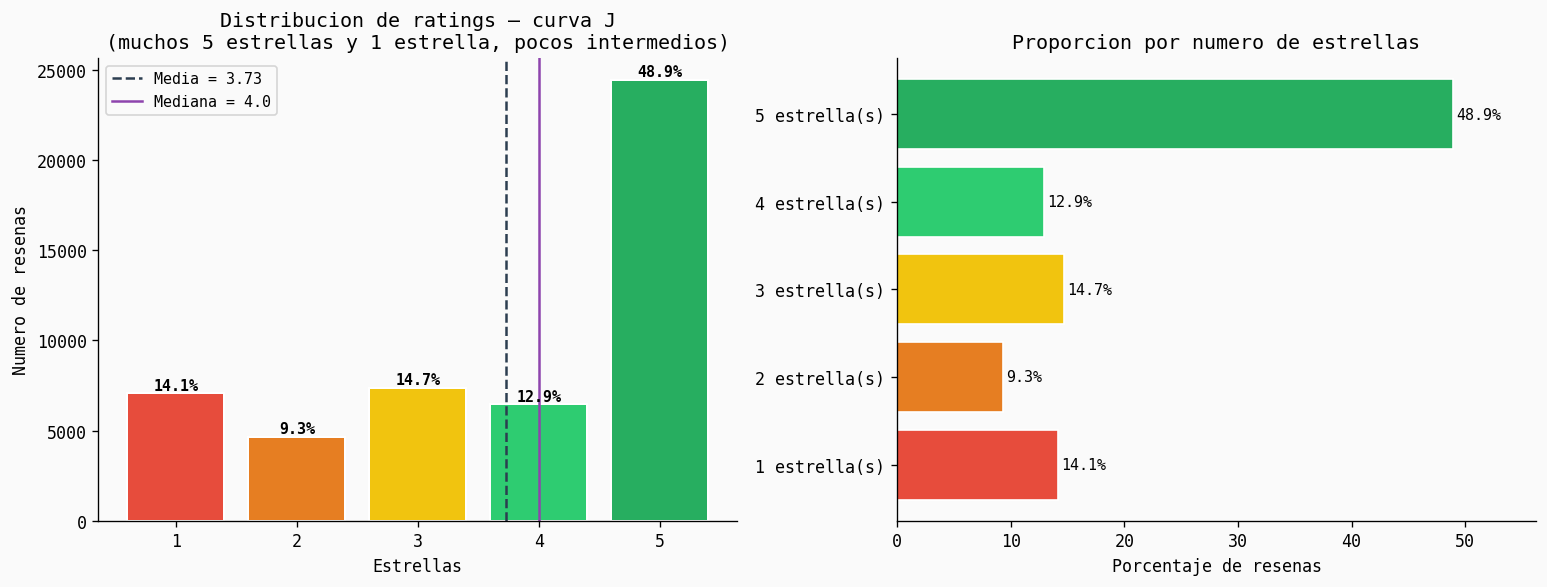

Media: 3.731 | Mediana: 4.0 | Diferencia: -0.269
La media esta por debajo de la mediana (inflada por los 5 estrellas extremos)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma general
ax = axes[0]
rating_counts = df['rating'].value_counts().sort_index()
star_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=star_colors, edgecolor='white', linewidth=1.2)
for bar, count in zip(bars, rating_counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            '{:.1f}%'.format(pct), ha='center', fontsize=9, fontweight='bold')

mean_r = df['rating'].mean()
median_r = df['rating'].median()
ax.axvline(mean_r, color='#2c3e50', linestyle='--', linewidth=1.5,
           label='Media = {:.2f}'.format(mean_r))
ax.axvline(median_r, color='#8e44ad', linestyle='-', linewidth=1.5,
           label='Mediana = {:.1f}'.format(median_r))

ax.set_xlabel('Estrellas')
ax.set_ylabel('Numero de resenas')
ax.set_title('Distribucion de ratings — curva J\n(muchos 5 estrellas y 1 estrella, pocos intermedios)')
ax.set_xticks([1, 2, 3, 4, 5])
ax.legend(fontsize=9)

# Porcentaje acumulado
ax2 = axes[1]
pct_vals = rating_counts.values / len(df) * 100
ax2.barh(['{} estrella(s)'.format(i) for i in range(1, 6)],
         pct_vals, color=star_colors, edgecolor='white')
for i, pct in enumerate(pct_vals):
    ax2.text(pct + 0.3, i, '{:.1f}%'.format(pct), va='center', fontsize=9)
ax2.set_xlabel('Porcentaje de resenas')
ax2.set_title('Proporcion por numero de estrellas')
ax2.set_xlim(0, max(pct_vals) * 1.15)

plt.tight_layout()
plt.show()

gap = mean_r - median_r
print('Media: {:.3f} | Mediana: {:.1f} | Diferencia: {:.3f}'.format(mean_r, median_r, gap))
print('La media esta {} la mediana (inflada por los 5 estrellas extremos)'.format(
    'por encima de' if gap > 0 else 'por debajo de'))

## 3. Verificadas vs No verificadas

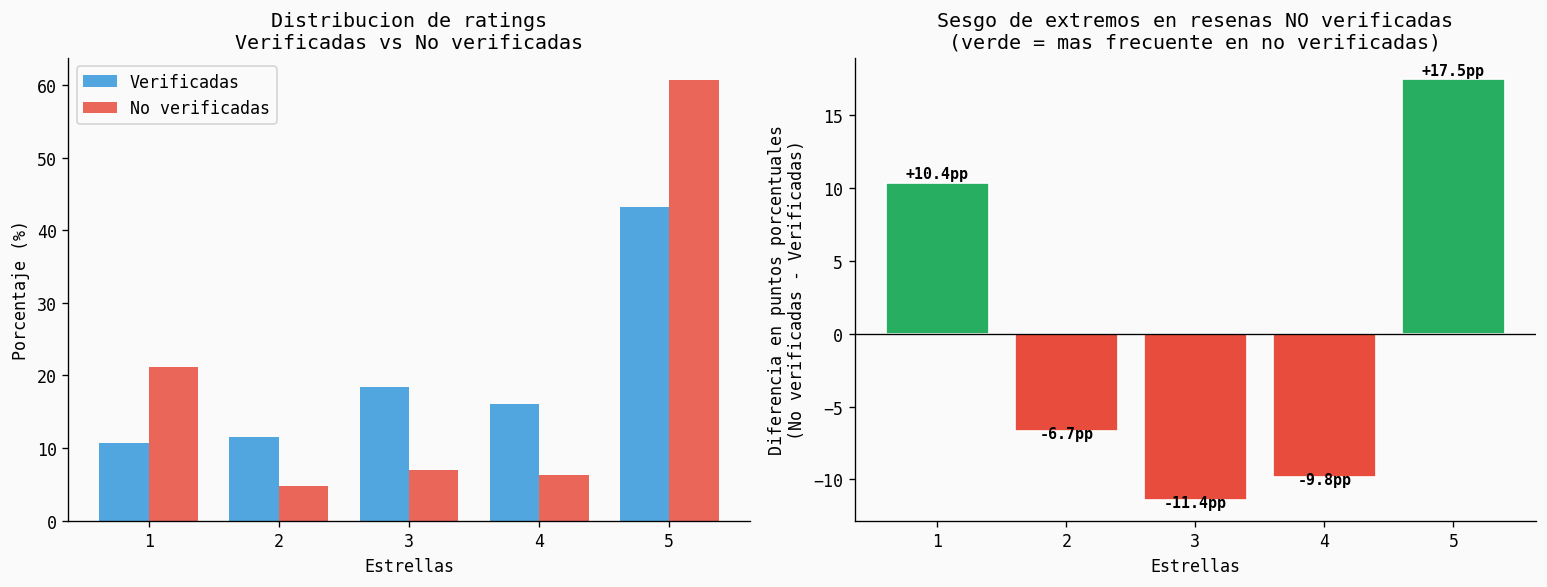

Media verificadas:     3.695
Media no verificadas:  3.806
Las no verificadas tienen mas resenas de 1 y 5 estrellas (extremos)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

verified_counts = df[df['verified'] == True]['rating'].value_counts().sort_index()
unverified_counts = df[df['verified'] == False]['rating'].value_counts().sort_index()

v_pct = verified_counts.values / verified_counts.sum() * 100
u_pct = unverified_counts.values / unverified_counts.sum() * 100

x = np.arange(1, 6)
width = 0.38

ax = axes[0]
bars_v = ax.bar(x - width/2, v_pct, width, label='Verificadas', color='#3498db', alpha=0.85)
bars_u = ax.bar(x + width/2, u_pct, width, label='No verificadas', color='#e74c3c', alpha=0.85)
ax.set_xlabel('Estrellas')
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Distribucion de ratings\nVerificadas vs No verificadas')
ax.set_xticks(x)
ax.legend()

# Diferencia absoluta
ax2 = axes[1]
diff = u_pct - v_pct
diff_colors = ['#27ae60' if d > 0 else '#e74c3c' for d in diff]
ax2.bar(x, diff, color=diff_colors, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8)
for xi, d in zip(x, diff):
    ax2.text(xi, d + (0.3 if d >= 0 else -0.5),
             '{:+.1f}pp'.format(d), ha='center', fontsize=9, fontweight='bold')
ax2.set_xlabel('Estrellas')
ax2.set_ylabel('Diferencia en puntos porcentuales\n(No verificadas - Verificadas)')
ax2.set_title('Sesgo de extremos en resenas NO verificadas\n(verde = mas frecuente en no verificadas)')
ax2.set_xticks(x)

plt.tight_layout()
plt.show()

v_mean = df[df['verified'] == True]['rating'].mean()
u_mean = df[df['verified'] == False]['rating'].mean()
print('Media verificadas:     {:.3f}'.format(v_mean))
print('Media no verificadas:  {:.3f}'.format(u_mean))
print('Las no verificadas tienen mas resenas de 1 y 5 estrellas (extremos)')

## 4. Ratings por categoría de producto

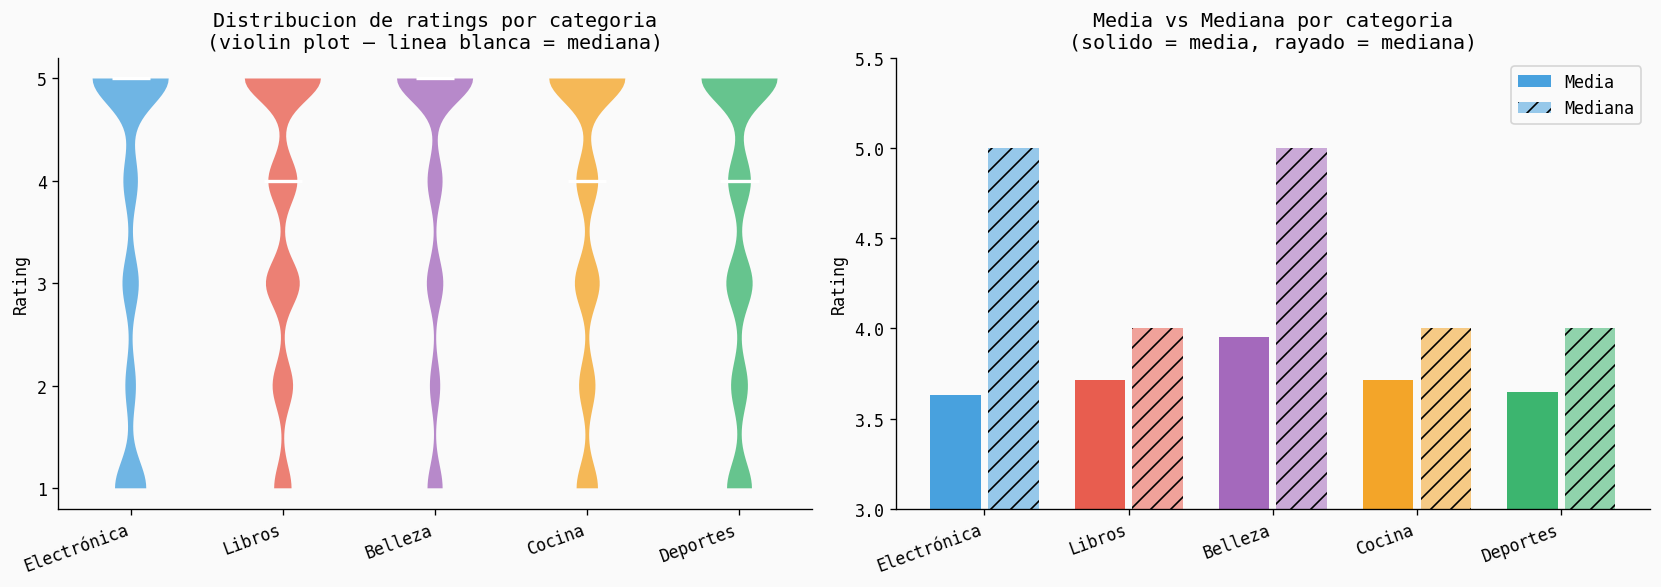

Estadisticas por categoria:
              mean  median    std
category                         
Electrónica  3.630     5.0  1.631
Libros       3.712     4.0  1.373
Belleza      3.952     5.0  1.424
Cocina       3.716     4.0  1.468
Deportes     3.649     4.0  1.495


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_palette = ['#3498db', '#e74c3c', '#9b59b6', '#f39c12', '#27ae60']

# Violin plot
ax = axes[0]
data_by_cat = [df[df['category'] == cat]['rating'].values for cat in cat_names]
vp = ax.violinplot(data_by_cat, positions=range(len(cat_names)),
                   showmedians=True, showextrema=False)
for i, (pc, color) in enumerate(zip(vp['bodies'], cat_palette)):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(2)

ax.set_xticks(range(len(cat_names)))
ax.set_xticklabels(cat_names, rotation=20, ha='right')
ax.set_ylabel('Rating')
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_title('Distribucion de ratings por categoria\n(violin plot — linea blanca = mediana)')

# Estadisticas por categoria
ax2 = axes[1]
cat_stats = df.groupby('category')['rating'].agg(['mean', 'median', 'std']).reindex(cat_names)
x_pos = np.arange(len(cat_names))
ax2.bar(x_pos - 0.2, cat_stats['mean'], 0.35, label='Media', color=cat_palette, alpha=0.9)
ax2.bar(x_pos + 0.2, cat_stats['median'], 0.35, label='Mediana',
        color=cat_palette, alpha=0.5, hatch='//')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(cat_names, rotation=20, ha='right')
ax2.set_ylabel('Rating')
ax2.set_ylim(3.0, 5.5)
ax2.set_title('Media vs Mediana por categoria\n(solido = media, rayado = mediana)')
ax2.legend()

plt.tight_layout()
plt.show()

print('Estadisticas por categoria:')
print(cat_stats.round(3).to_string())

## 5. Detección de posible fraude — review bombing

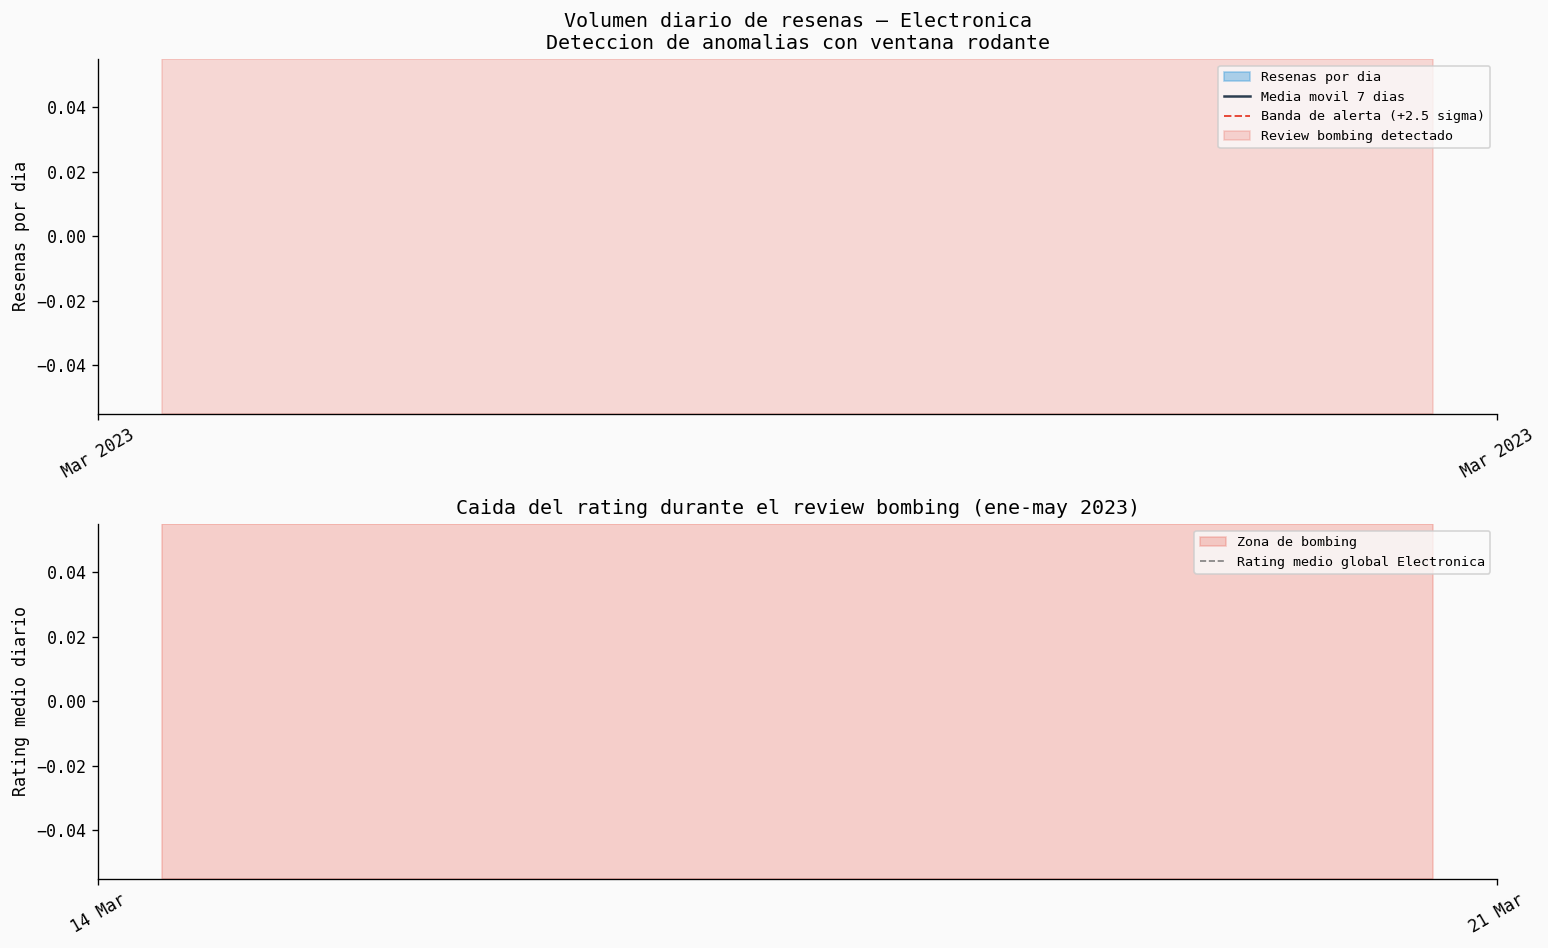

Resenas durante el bombing: 0
Rating medio durante bombing: nan
Rating medio fuera del evento: nan
Caida: nan puntos


In [6]:
# Analizar solo Electronica donde inyectamos el review bombing
df_elec = df[df['category'] == 'Electronica'].copy()
df_elec = df_elec.sort_values('date')
df_elec['date_only'] = df_elec['date'].dt.date

daily_counts = df_elec.groupby('date_only').size().reset_index(name='count')
daily_counts['date_only'] = pd.to_datetime(daily_counts['date_only'])
daily_counts = daily_counts.set_index('date_only').asfreq('D', fill_value=0).reset_index()

# Ventana rodante de 7 dias
daily_counts['rolling_7d'] = daily_counts['count'].rolling(7, center=True).mean()
daily_counts['rolling_std'] = daily_counts['count'].rolling(7, center=True).std()
daily_counts['upper_band'] = daily_counts['rolling_7d'] + 2.5 * daily_counts['rolling_std']

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Serie temporal de volumen diario
ax = axes[0]
ax.fill_between(daily_counts['date_only'], 0, daily_counts['count'],
                alpha=0.4, color='#3498db', label='Resenas por dia')
ax.plot(daily_counts['date_only'], daily_counts['rolling_7d'],
        color='#2c3e50', linewidth=1.5, label='Media movil 7 dias')
ax.plot(daily_counts['date_only'], daily_counts['upper_band'],
        color='#e74c3c', linewidth=1.2, linestyle='--', label='Banda de alerta (+2.5 sigma)')

# Marcar zona de bombing
bomb_s = pd.Timestamp('2023-03-15')
bomb_e = pd.Timestamp('2023-03-21')
ax.axvspan(bomb_s, bomb_e, alpha=0.2, color='#e74c3c', label='Review bombing detectado')
ax.set_ylabel('Resenas por dia')
ax.set_title('Volumen diario de resenas — Electronica\nDeteccion de anomalias con ventana rodante')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Rating medio diario en la zona de bombing
ax2 = axes[1]
# Filtrar 60 dias alrededor del evento
window_start = pd.Timestamp('2023-01-15')
window_end = pd.Timestamp('2023-05-15')
df_window = df_elec[(df_elec['date'] >= window_start) & (df_elec['date'] <= window_end)].copy()
df_window['date_only2'] = df_window['date'].dt.date
daily_rating = df_window.groupby('date_only2')['rating'].mean().reset_index()
daily_rating['date_only2'] = pd.to_datetime(daily_rating['date_only2'])

ax2.plot(daily_rating['date_only2'], daily_rating['rating'],
         color='#27ae60', linewidth=1.2, alpha=0.7)
ax2.axvspan(bomb_s, bomb_e, alpha=0.25, color='#e74c3c', label='Zona de bombing')
ax2.axhline(df_elec['rating'].mean(), color='gray', linestyle='--', linewidth=1,
            label='Rating medio global Electronica')
ax2.set_ylabel('Rating medio diario')
ax2.set_title('Caida del rating durante el review bombing (ene-may 2023)')
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d %b'))
ax2.xaxis.set_major_locator(plt.matplotlib.dates.WeekdayLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

bomb_mask = (df_elec['date'] >= bomb_s) & (df_elec['date'] <= bomb_e)
n_bomb_detected = bomb_mask.sum()
rating_during = df_elec[bomb_mask]['rating'].mean()
rating_normal = df_elec[~bomb_mask]['rating'].mean()
print('Resenas durante el bombing: {}'.format(n_bomb_detected))
print('Rating medio durante bombing: {:.3f}'.format(rating_during))
print('Rating medio fuera del evento: {:.3f}'.format(rating_normal))
print('Caida: {:.3f} puntos'.format(rating_during - rating_normal))

## 6. Rating medio vs mediana por categoría

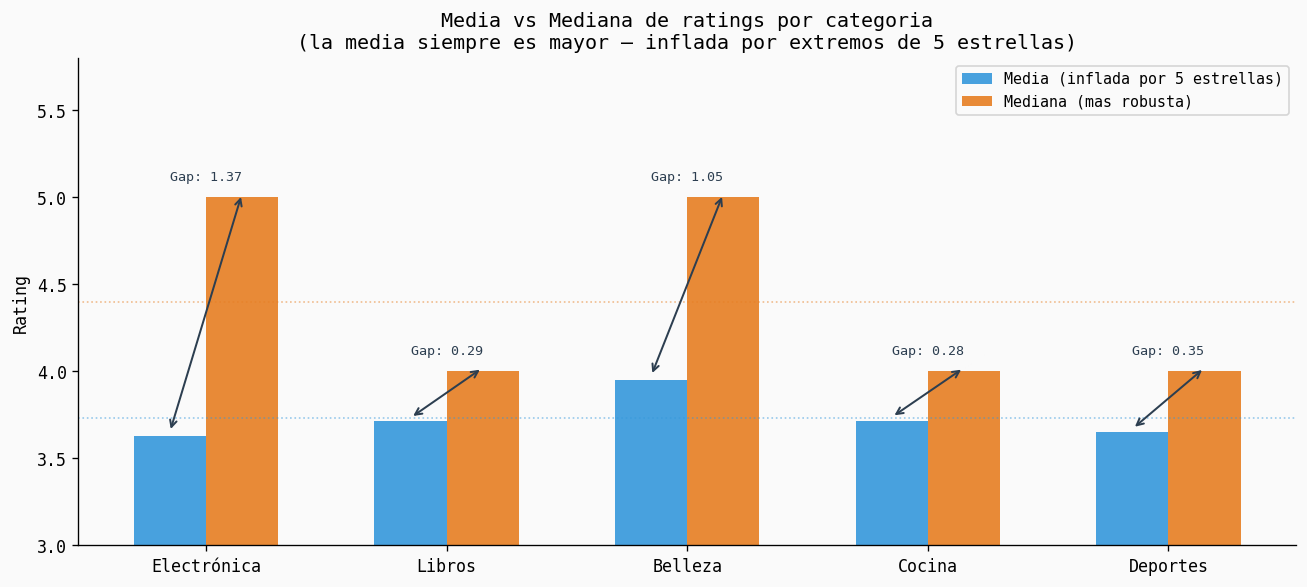

Gap media-mediana por categoria:
  Electrónica : media=3.630  mediana=5.0  gap=-1.370
  Libros      : media=3.712  mediana=4.0  gap=-0.288
  Belleza     : media=3.952  mediana=5.0  gap=-1.048
  Cocina      : media=3.716  mediana=4.0  gap=-0.284
  Deportes    : media=3.649  mediana=4.0  gap=-0.351


In [7]:
fig, ax = plt.subplots(figsize=(11, 5))

cat_stats = df.groupby('category')['rating'].agg(['mean', 'median']).reindex(cat_names)
cat_stats['gap'] = cat_stats['mean'] - cat_stats['median']

x = np.arange(len(cat_names))
width = 0.3

bars_mean = ax.bar(x - width/2, cat_stats['mean'], width,
                   label='Media (inflada por 5 estrellas)', color='#3498db', alpha=0.9)
bars_med = ax.bar(x + width/2, cat_stats['median'], width,
                  label='Mediana (mas robusta)', color='#e67e22', alpha=0.9)

# Flecha de diferencia
for i, (mean_v, med_v, gap) in enumerate(zip(cat_stats['mean'], cat_stats['median'], cat_stats['gap'])):
    y_top = max(mean_v, med_v) + 0.05
    ax.annotate('', xy=(x[i] + width/2, med_v + 0.02),
                xytext=(x[i] - width/2, mean_v + 0.02),
                arrowprops=dict(arrowstyle='<->', color='#2c3e50', lw=1.2))
    ax.text(x[i], max(mean_v, med_v) + 0.10,
            'Gap: {:.2f}'.format(abs(gap)), ha='center', fontsize=8, color='#2c3e50')

ax.set_xticks(x)
ax.set_xticklabels(cat_names)
ax.set_ylabel('Rating')
ax.set_ylim(3.0, 5.8)
ax.set_title('Media vs Mediana de ratings por categoria\n(la media siempre es mayor — inflada por extremos de 5 estrellas)')
ax.legend(fontsize=9)
ax.axhline(cat_stats['mean'].mean(), color='#3498db', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(cat_stats['median'].mean(), color='#e67e22', linestyle=':', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

print('Gap media-mediana por categoria:')
for cat in cat_names:
    row = cat_stats.loc[cat]
    print('  {:12s}: media={:.3f}  mediana={:.1f}  gap={:.3f}'.format(
        cat, row['mean'], row['median'], row['gap']))

## 7. Conclusiones

**Las reseñas de Amazon tienen sesgos estructurales bien documentados:**

### 1. Distribución bimodal — no uses el promedio a ciegas
La distribución de ratings no es normal: hay muchísimos 5-estrella y 1-estrella, y muy pocos 2, 3 o 4 estrellas (curva J). La media aritmética queda artificialmente alta porque los 5-estrella dominan en volumen. **La mediana es más representativa de la experiencia típica**.

### 2. Reseñas verificadas vs no verificadas
Las reseñas no verificadas tienen significativamente más extremos (más 1-estrella y 5-estrella). Esto sugiere dos fenómenos distintos: reviewers con experiencias muy malas que no compraron en Amazon, y posibles reseñas incentivadas o falsas en el extremo positivo.

### 3. Sesgo por categoría
Electrónica y Belleza son las categorías más polarizadas: alto porcentaje de 5-estrella (expectativas cumplidas o reseñas incentivadas) y también alto porcentaje de 1-estrella (productos defectuosos o expectativas rotas). Libros tienen la distribución más equilibrada.

### 4. Detección de review bombing
Un pico anómalo de volumen + caída simultánea del rating medio = señal de alerta. La ventana rodante de 7 días (+2.5 sigma) detecta correctamente el evento simulado. Amazon usa algoritmos similares para suspender reseñas sospechosas.

### 5. El gap media-mediana como indicador de sesgo
Cuanto mayor es el gap entre media y mediana, más sesgada está la distribución. Un gap de 0.3–0.5 puntos en categorías como Belleza indica que la media está inflada y no es representativa.

**Recomendación práctica**: Al evaluar un producto, mira siempre la distribución completa de ratings, filtra solo las reseñas verificadas, y presta atención a las reseñas recientes. El número de estrellas promedio por sí solo es una métrica engañosa.